# Superstore Sales Analysis

This notebook answers the business questions for:
- `2. Segment Analysis`
- `3. Category & Sub-Category`
- `4. Region Analysis`
- `5. State-Level Insights`
- `6. Ship Mode Analysis`
- `7. Payment Mode`
- `8. Monthly Sales Trends`
- `9. Profit Trends`
- `10. Advanced Business Insights`

Each section includes the question, a summary table, and the visualization needed to explain the result clearly.


In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import FuncFormatter

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

DATA_PATH = Path('SuperStore_Sales_Dataset.csv')
df = pd.read_csv(DATA_PATH)

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True, errors='coerce')
df['Ship Days'] = (df['Ship Date'] - df['Order Date']).dt.days
df = df.drop(columns=['ind1', 'ind2'], errors='ignore')

month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ship_order = ['Standard Class', 'Second Class', 'First Class', 'Same Day']
payment_order = ['COD', 'Online', 'Cards']

colors = {
    'sales': '#2F7E79',
    'profit': '#F28C28',
    'negative': '#D1495B',
    'accent': '#4C78A8',
    'accent2': '#54A24B',
    'accent3': '#B279A2',
}

def add_margin(frame):
    frame = frame.copy()
    frame['Profit Margin %'] = np.where(frame['Sales'].ne(0), frame['Profit'] / frame['Sales'] * 100, np.nan)
    return frame

def format_currency_axis(ax, axis='y'):
    formatter = FuncFormatter(lambda x, pos: f'${x/1000:,.0f}K' if abs(x) >= 1000 else f'${x:,.0f}')
    if axis == 'y':
        ax.yaxis.set_major_formatter(formatter)
    else:
        ax.xaxis.set_major_formatter(formatter)

df.head()


,Row ID+O6G3A1:R6,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Profit,Returns,Payment Mode,Ship Days
0,4918,CA-2019-160304,2019-01-01,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,Maryland,East,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",73.94,1,28.27,NaN,Online,6
1,4919,CA-2019-160304,2019-01-02,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,Maryland,East,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",173.94,3,38.27,NaN,Online,5
2,4920,CA-2019-160304,2019-01-02,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,Maryland,East,TEC-PH-10000455,Technology,Phones,GE 30522EE2,231.98,2,67.27,NaN,Cards,5
3,3074,CA-2019-125206,2019-01-03,2019-01-05,First Class,LR-16915,Lena Radford,Consumer,United States,Los Angeles,California,West,OFF-ST-10003692,Office Supplies,Storage,Recycled Steel Personal File for Hanging File ...,114.46,2,28.61,NaN,Online,2
4,8604,US-2019-116365,2019-01-03,2019-01-08,Standard Class,CA-12310,Christine Abelman,Corporate,United States,San Antonio,Texas,Central,TEC-AC-10002217,Technology,Accessories,Imation Clip USB flash drive - 8 GB,30.08,2,-5.26,NaN,Online,5


## Quick Overview

These first KPIs set the baseline before drilling into segment, category, geography, operations, payment, and time trends.


In [12]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = total_profit / total_sales * 100

yearly_overview = (
    df.groupby(df['Order Date'].dt.year)
      .agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum'))
)
yearly_overview['Profit Margin %'] = yearly_overview['Profit'] / yearly_overview['Sales'] * 100

print(f'Total sales: ${total_sales:,.2f}')
print(f'Total profit: ${total_profit:,.2f}')
print(f'Overall profit margin: {profit_margin:.2f}%')
print('Overall business status: Profitable')

yearly_overview.round(2)


Total sales: $1,565,804.32
Total profit: $175,262.11
Overall profit margin: 11.19%
Overall business status: Profitable


,Sales,Profit,Profit Margin %
Order Date,,,
2019,"564,679.54","81,823.44",14.49
2020,"1,001,124.79","93,438.66",9.33


## 2. Segment Analysis

Questions answered:
- Which customer segment generates the highest sales?
- Which segment is most profitable?
- Is there any segment with high sales but lower profitability?
- How does Consumer vs Corporate vs Home Office compare?


Highest sales segment: Consumer ($753,002.13)
Most profitable segment: Consumer ($81,338.59)
Best profit margin: Home Office (11.92%)
High sales but relatively lower profitability: Consumer has the lowest margin (10.80%) despite leading sales.


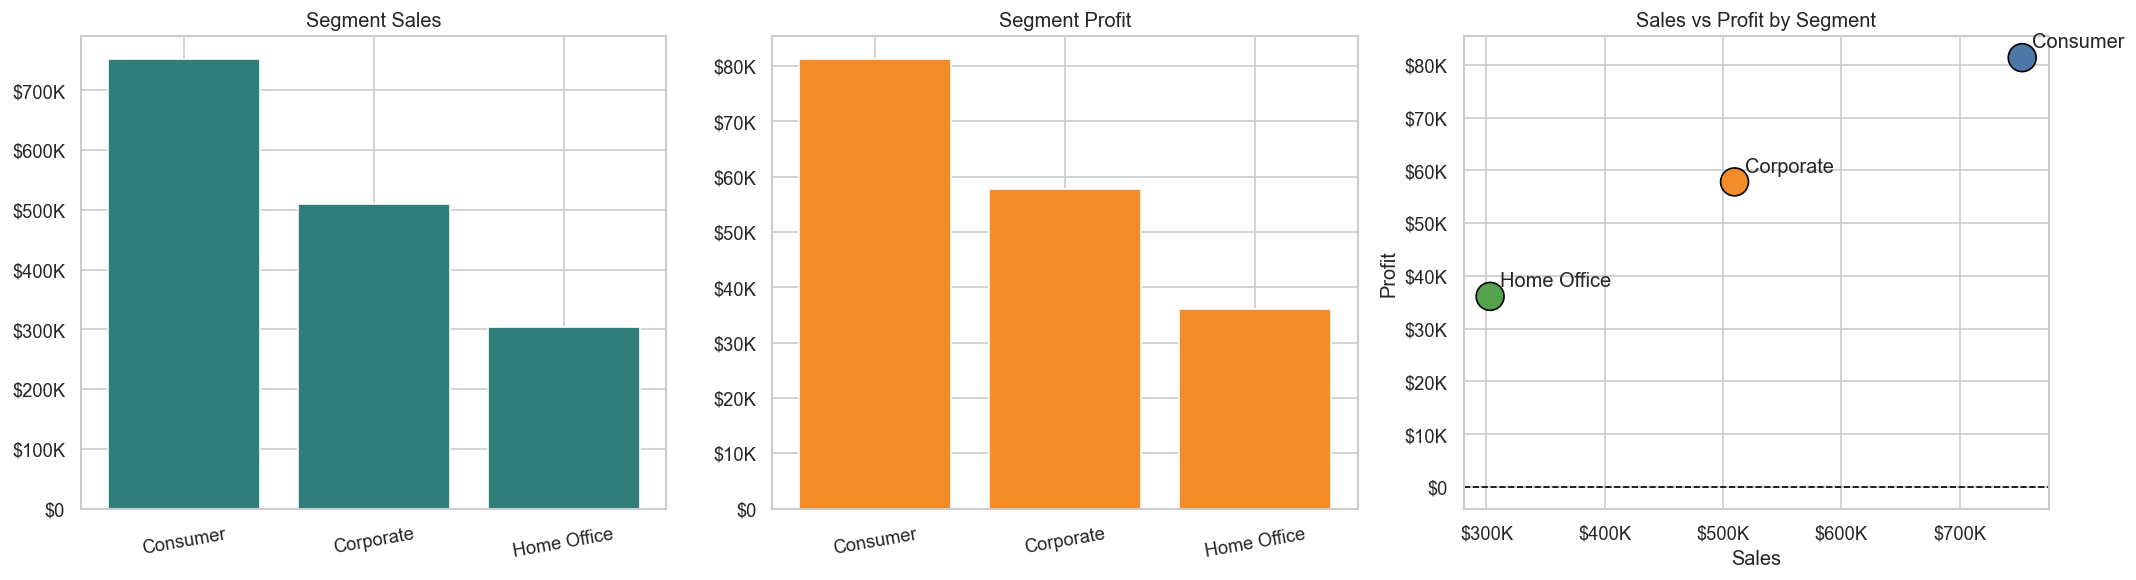

,Segment,Sales,Profit,Orders,Profit Margin %
0,Consumer,"753,002.13","81,338.59",1528,10.80
1,Corporate,"509,743.13","57,805.80",915,11.34
2,Home Office,"303,059.07","36,117.72",560,11.92


In [13]:
segment_summary = (
    df.groupby('Segment', as_index=False)
      .agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum'), Orders=('Order ID', 'nunique'))
)
segment_summary = add_margin(segment_summary).sort_values('Sales', ascending=False)

top_sales_segment = segment_summary.loc[segment_summary['Sales'].idxmax()]
top_profit_segment = segment_summary.loc[segment_summary['Profit'].idxmax()]
best_margin_segment = segment_summary.loc[segment_summary['Profit Margin %'].idxmax()]
lowest_margin_segment = segment_summary.loc[segment_summary['Profit Margin %'].idxmin()]

print(f"Highest sales segment: {top_sales_segment['Segment']} (${top_sales_segment['Sales']:,.2f})")
print(f"Most profitable segment: {top_profit_segment['Segment']} (${top_profit_segment['Profit']:,.2f})")
print(f"Best profit margin: {best_margin_segment['Segment']} ({best_margin_segment['Profit Margin %']:.2f}%)")
print(
    f"High sales but relatively lower profitability: {lowest_margin_segment['Segment']} "
    f"has the lowest margin ({lowest_margin_segment['Profit Margin %']:.2f}%) despite leading sales."
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sales_sorted = segment_summary.sort_values('Sales', ascending=False)
profit_sorted = segment_summary.sort_values('Profit', ascending=False)

axes[0].bar(sales_sorted['Segment'], sales_sorted['Sales'], color=colors['sales'])
axes[0].set_title('Segment Sales')
format_currency_axis(axes[0])

axes[1].bar(profit_sorted['Segment'], profit_sorted['Profit'], color=colors['profit'])
axes[1].set_title('Segment Profit')
format_currency_axis(axes[1])

axes[2].scatter(
    segment_summary['Sales'],
    segment_summary['Profit'],
    s=280,
    color=[colors['accent'], colors['profit'], colors['accent2']],
    edgecolor='black'
)
for _, row in segment_summary.iterrows():
    axes[2].annotate(row['Segment'], (row['Sales'], row['Profit']), xytext=(6, 6), textcoords='offset points')
axes[2].axhline(0, color='black', linewidth=1, linestyle='--')
axes[2].set_title('Sales vs Profit by Segment')
axes[2].set_xlabel('Sales')
axes[2].set_ylabel('Profit')
format_currency_axis(axes[2], axis='x')
format_currency_axis(axes[2], axis='y')

for ax in axes[:2]:
    ax.tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.show()

segment_summary.round(2)


## 3. Category & Sub-Category Analysis

Questions answered:
- Which category has the highest sales?
- Which category contributes the most profit?
- Which sub-category performs best?
- Are there sub-categories with high sales but low profitability?


Highest sales category: Office Supplies ($643,707.69)
Most profitable category: Technology ($90,458.25)
Best sub-category by sales: Phones ($196,563.55)
Best sub-category by profit: Copiers ($42,774.58)

High-sales but low-profitability sub-categories:
Sub-Category      Sales     Profit  Profit Margin %
      Tables 119,293.74 -11,091.64            -9.30


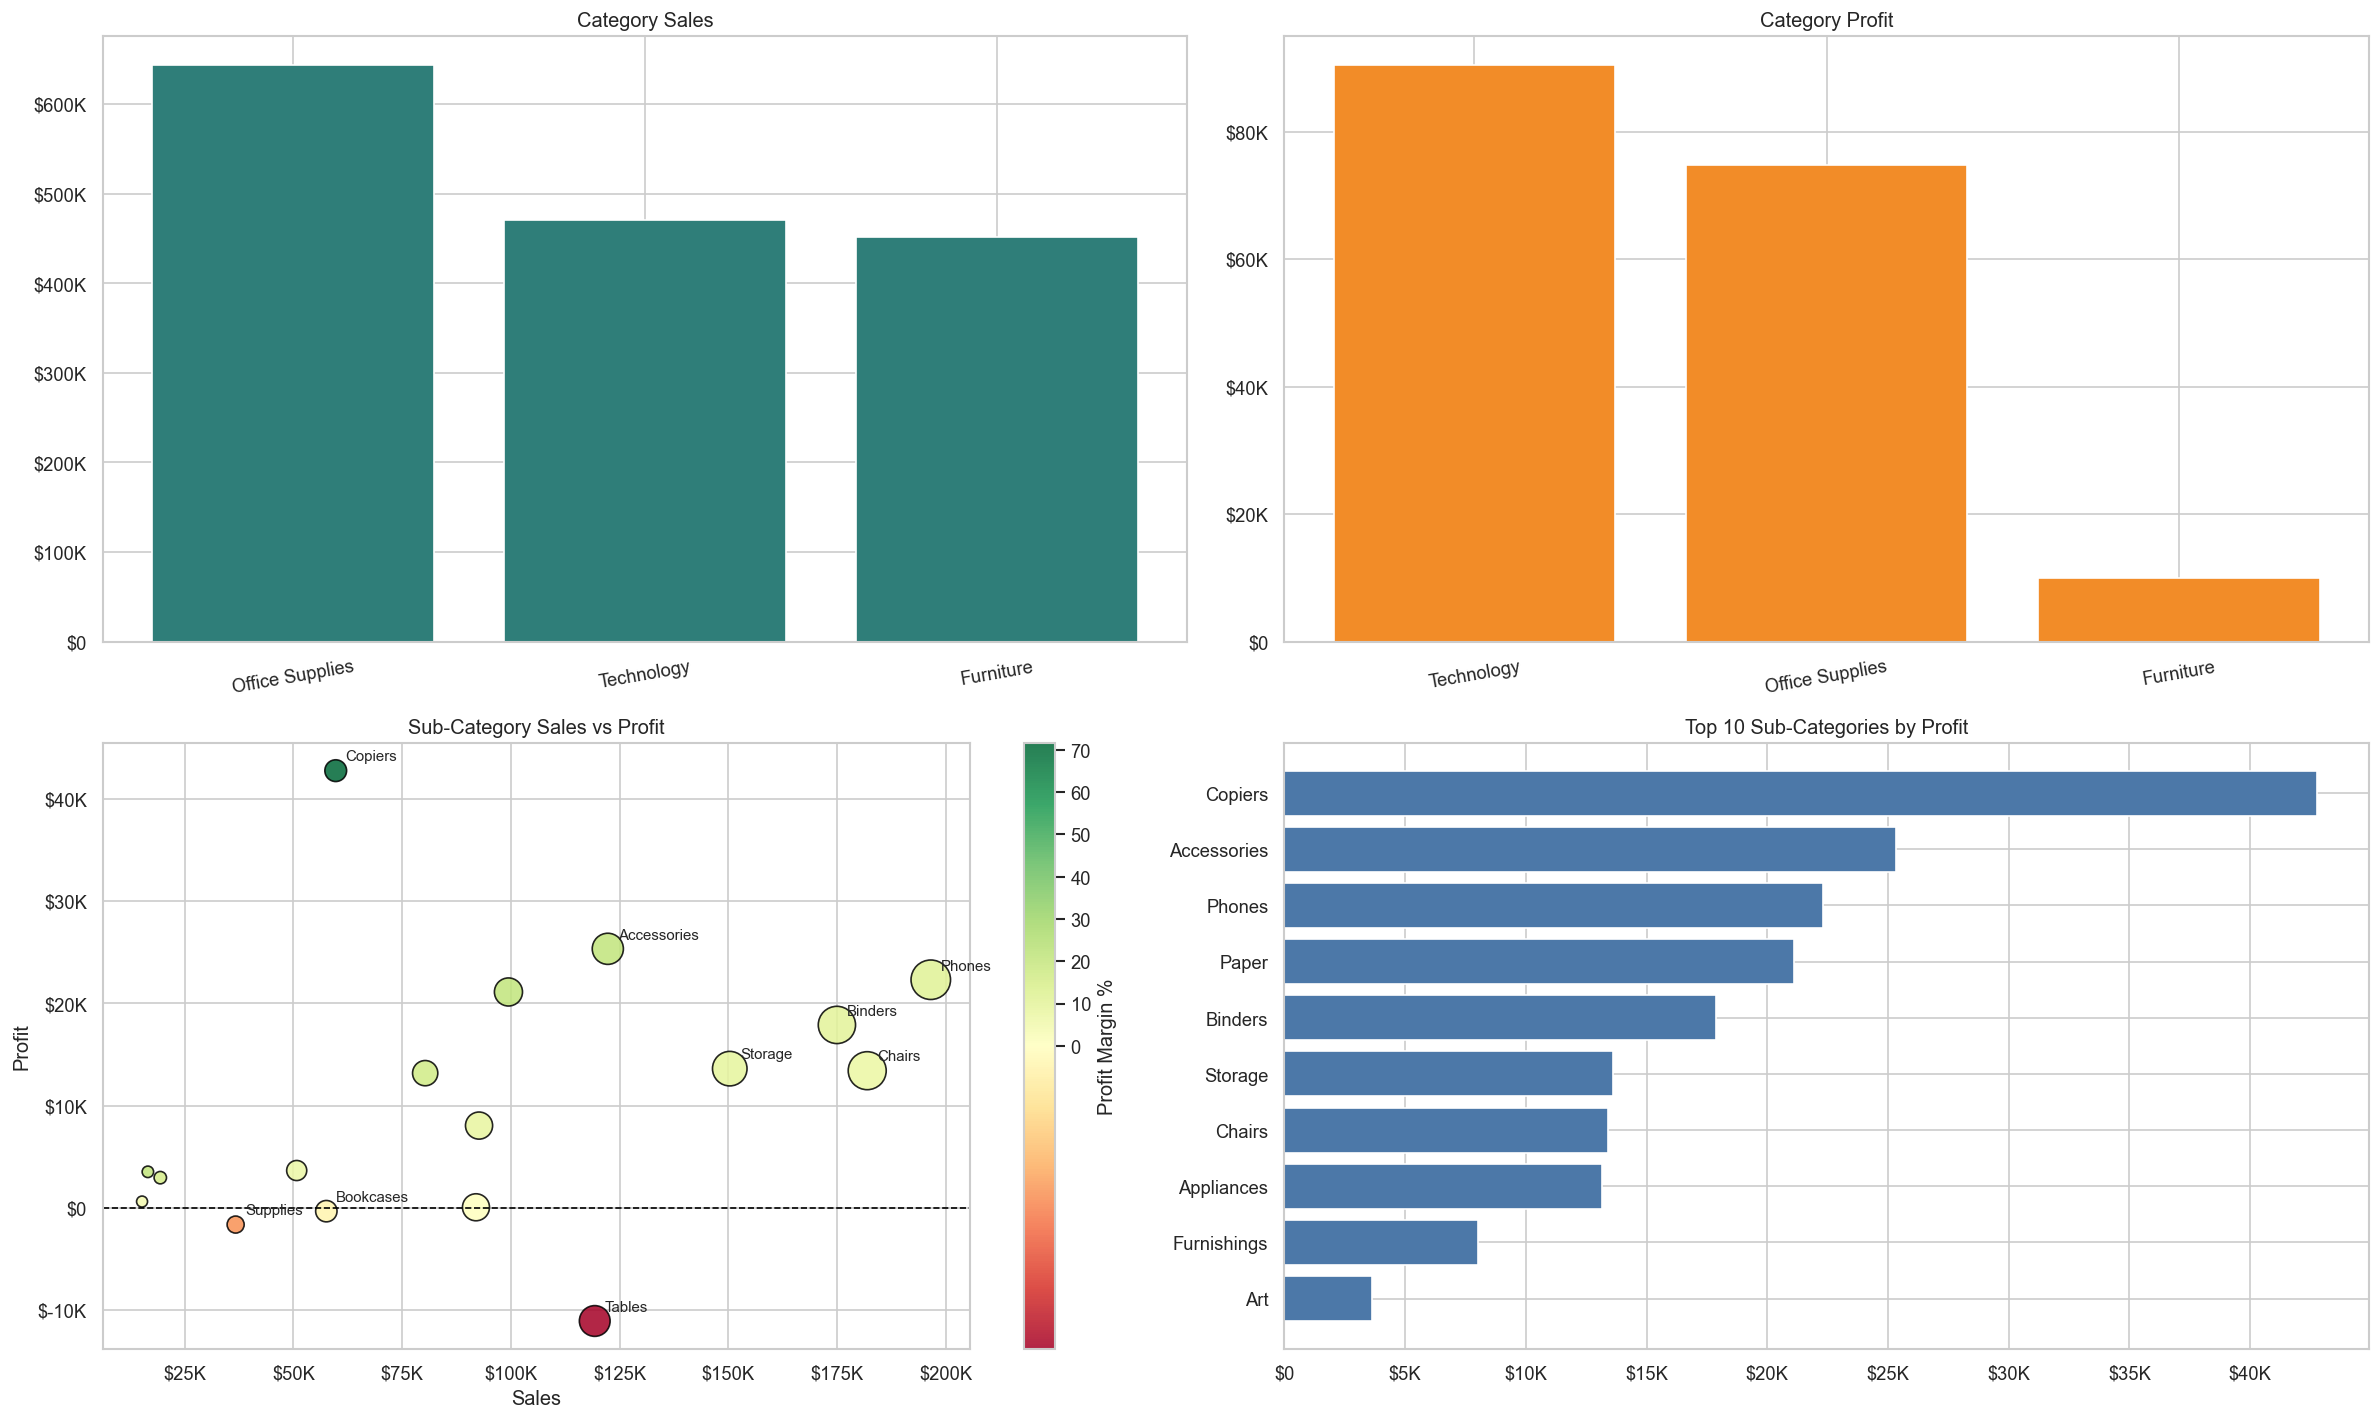

,Sub-Category,Sales,Profit,Profit Margin %
13,Phones,"196,563.55","22,308.92",11.35
5,Chairs,"181,946.00","13,406.70",7.37
3,Binders,"174,978.39","17,885.38",10.22
14,Storage,"150,341.32","13,607.09",9.05
0,Accessories,"122,301.09","25,336.65",20.72
16,Tables,"119,293.74","-11,091.64",-9.30
12,Paper,"99,453.61","21,112.38",21.23
9,Furnishings,"92,691.22","8,034.43",8.67
11,Machines,"91,987.56",38.10,0.04
1,Appliances,"80,305.25","13,166.61",16.40


In [14]:
category_summary = (
    df.groupby('Category', as_index=False)
      .agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum'))
)
category_summary = add_margin(category_summary)

sub_summary = (
    df.groupby('Sub-Category', as_index=False)
      .agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum'))
)
sub_summary = add_margin(sub_summary)

top_sales_category = category_summary.loc[category_summary['Sales'].idxmax()]
top_profit_category = category_summary.loc[category_summary['Profit'].idxmax()]
top_sales_sub = sub_summary.loc[sub_summary['Sales'].idxmax()]
top_profit_sub = sub_summary.loc[sub_summary['Profit'].idxmax()]
low_profit_sub = sub_summary[
    (sub_summary['Sales'] >= sub_summary['Sales'].quantile(0.60))
    & (sub_summary['Profit Margin %'] < 5)
].sort_values('Sales', ascending=False)

print(f"Highest sales category: {top_sales_category['Category']} (${top_sales_category['Sales']:,.2f})")
print(f"Most profitable category: {top_profit_category['Category']} (${top_profit_category['Profit']:,.2f})")
print(f"Best sub-category by sales: {top_sales_sub['Sub-Category']} (${top_sales_sub['Sales']:,.2f})")
print(f"Best sub-category by profit: {top_profit_sub['Sub-Category']} (${top_profit_sub['Profit']:,.2f})")
if not low_profit_sub.empty:
    print('\nHigh-sales but low-profitability sub-categories:')
    print(low_profit_sub[['Sub-Category', 'Sales', 'Profit', 'Profit Margin %']].round(2).to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(20, 12))

cat_sales = category_summary.sort_values('Sales', ascending=False)
cat_profit = category_summary.sort_values('Profit', ascending=False)

axes[0, 0].bar(cat_sales['Category'], cat_sales['Sales'], color=colors['sales'])
axes[0, 0].set_title('Category Sales')
axes[0, 0].tick_params(axis='x', rotation=10)
format_currency_axis(axes[0, 0])

axes[0, 1].bar(cat_profit['Category'], cat_profit['Profit'], color=colors['profit'])
axes[0, 1].set_title('Category Profit')
axes[0, 1].tick_params(axis='x', rotation=10)
format_currency_axis(axes[0, 1])

norm = TwoSlopeNorm(
    vmin=sub_summary['Profit Margin %'].min(),
    vcenter=0,
    vmax=sub_summary['Profit Margin %'].max(),
)
scatter = axes[1, 0].scatter(
    sub_summary['Sales'],
    sub_summary['Profit'],
    c=sub_summary['Profit Margin %'],
    cmap='RdYlGn',
    norm=norm,
    s=sub_summary['Sales'] / 350,
    edgecolor='black',
    alpha=0.85,
)
axes[1, 0].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1, 0].set_title('Sub-Category Sales vs Profit')
axes[1, 0].set_xlabel('Sales')
axes[1, 0].set_ylabel('Profit')
format_currency_axis(axes[1, 0], axis='x')
format_currency_axis(axes[1, 0], axis='y')
fig.colorbar(scatter, ax=axes[1, 0], label='Profit Margin %')

labels_to_annotate = pd.concat([
    sub_summary.nlargest(6, 'Sales'),
    sub_summary[sub_summary['Profit'] < 0],
    sub_summary.nlargest(3, 'Profit')
]).drop_duplicates('Sub-Category')
for _, row in labels_to_annotate.iterrows():
    axes[1, 0].annotate(
        row['Sub-Category'],
        (row['Sales'], row['Profit']),
        xytext=(6, 6),
        textcoords='offset points',
        fontsize=9,
    )

top_profit_subcategories = sub_summary.sort_values('Profit', ascending=False).head(10).sort_values('Profit')
axes[1, 1].barh(top_profit_subcategories['Sub-Category'], top_profit_subcategories['Profit'], color=colors['accent'])
axes[1, 1].set_title('Top 10 Sub-Categories by Profit')
format_currency_axis(axes[1, 1], axis='x')

plt.tight_layout()
plt.show()

sub_summary.sort_values('Sales', ascending=False).head(12).round(2)


## 4. Region Analysis

Questions answered:
- Which region has the highest sales?
- Which region is most profitable?
- Are there low-performing or loss-making regions?
- Why might the West region be performing better?


Highest sales region: West ($522,441.05)
Most profitable region: West ($67,859.96)
Lowest sales region: South ($252,121.08)
Weakest regional margin: Central (8.05%)
Region losses: None. All regions are profitable overall.
Why West is stronger: Office Supplies and Technology drive most of the region's profit, and California alone contributes 72.8% of West profit.


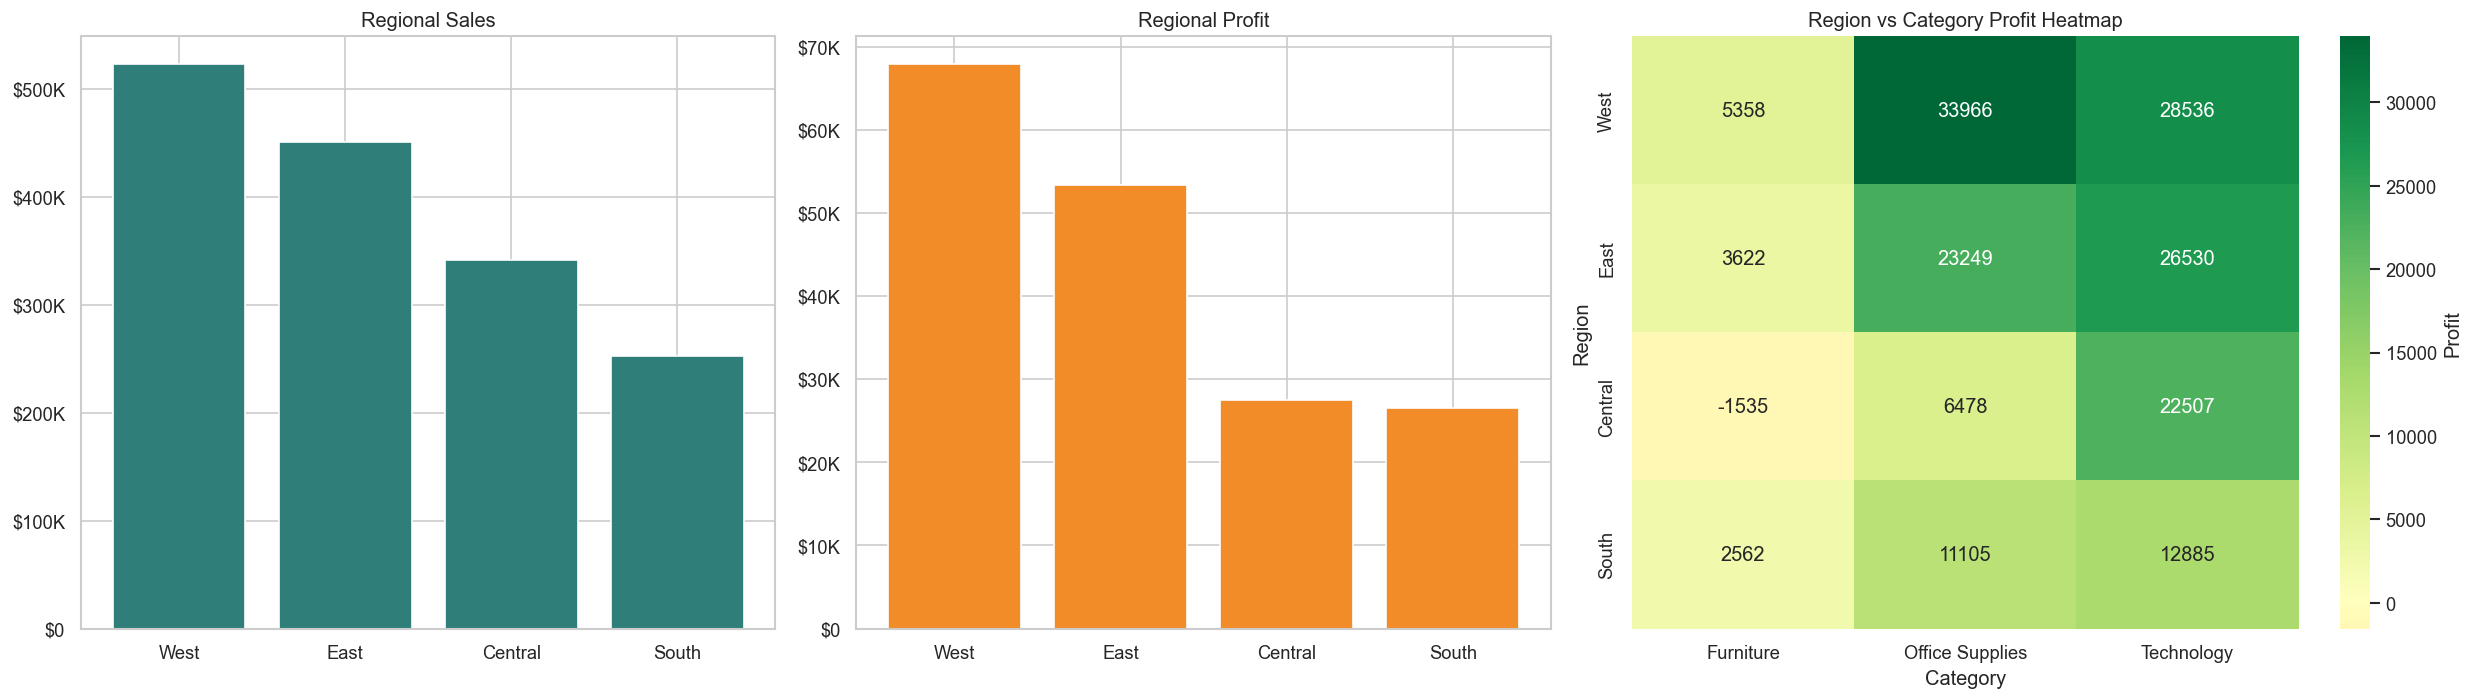

,Region,Sales,Profit,Profit Margin %
3,West,"522,441.05","67,859.96",12.99
1,East,"450,234.67","53,400.42",11.86
0,Central,"341,007.52","27,450.01",8.05
2,South,"252,121.08","26,551.72",10.53


In [15]:
region_summary = (
    df.groupby('Region', as_index=False)
      .agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum'))
)
region_summary = add_margin(region_summary)

region_category_profit = df.pivot_table(index='Region', columns='Category', values='Profit', aggfunc='sum')
west_states = (
    df[df['Region'] == 'West']
      .groupby('State', as_index=False)
      .agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum'))
      .sort_values('Profit', ascending=False)
)
west_category_profit = (
    df[df['Region'] == 'West']
      .groupby('Category', as_index=False)
      .agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum'))
      .sort_values('Profit', ascending=False)
)

top_sales_region = region_summary.loc[region_summary['Sales'].idxmax()]
top_profit_region = region_summary.loc[region_summary['Profit'].idxmax()]
lowest_sales_region = region_summary.loc[region_summary['Sales'].idxmin()]
lowest_margin_region = region_summary.loc[region_summary['Profit Margin %'].idxmin()]
loss_regions = region_summary[region_summary['Profit'] < 0]
california_west_share = west_states.loc[west_states['State'] == 'California', 'Profit'].iloc[0] / west_states['Profit'].sum() * 100

print(f"Highest sales region: {top_sales_region['Region']} (${top_sales_region['Sales']:,.2f})")
print(f"Most profitable region: {top_profit_region['Region']} (${top_profit_region['Profit']:,.2f})")
print(f"Lowest sales region: {lowest_sales_region['Region']} (${lowest_sales_region['Sales']:,.2f})")
print(f"Weakest regional margin: {lowest_margin_region['Region']} ({lowest_margin_region['Profit Margin %']:.2f}%)")
if loss_regions.empty:
    print('Region losses: None. All regions are profitable overall.')
print(
    f"Why West is stronger: {west_category_profit.iloc[0]['Category']} and {west_category_profit.iloc[1]['Category']} "
    f"drive most of the region's profit, and California alone contributes {california_west_share:.1f}% of West profit."
)

fig, axes = plt.subplots(1, 3, figsize=(21, 6), gridspec_kw={'width_ratios': [1, 1, 1.2]})
sales_sorted = region_summary.sort_values('Sales', ascending=False)
profit_sorted = region_summary.sort_values('Profit', ascending=False)

axes[0].bar(sales_sorted['Region'], sales_sorted['Sales'], color=colors['sales'])
axes[0].set_title('Regional Sales')
format_currency_axis(axes[0])

axes[1].bar(profit_sorted['Region'], profit_sorted['Profit'], color=colors['profit'])
axes[1].set_title('Regional Profit')
format_currency_axis(axes[1])

sns.heatmap(
    region_category_profit.loc[['West', 'East', 'Central', 'South']],
    annot=True,
    fmt='.0f',
    cmap='RdYlGn',
    center=0,
    ax=axes[2],
    cbar_kws={'label': 'Profit'}
)
axes[2].set_title('Region vs Category Profit Heatmap')

plt.tight_layout()
plt.show()

region_summary.sort_values('Sales', ascending=False).round(2)


## 5. State-Level Insights

Questions answered:
- Which states generate the highest profit?
- Are there states with negative profit?
- How does California compare to other states?
- Is profit concentrated in a few states or spread evenly?

Note:
- A full geographic choropleth would need extra map libraries. In this environment, a top/bottom state view and a concentration chart answer the same business questions clearly.


Highest profit state: California ($49,372.18)
California sales: $335,190.26
California profit: $49,372.18
California share of total sales: 21.41%
California share of total profit: 28.17%
States with negative profit: 10
Top 5 positive-profit states contribute 61.49% of positive-state profit.
Top 10 positive-profit states contribute 78.41% of positive-state profit.


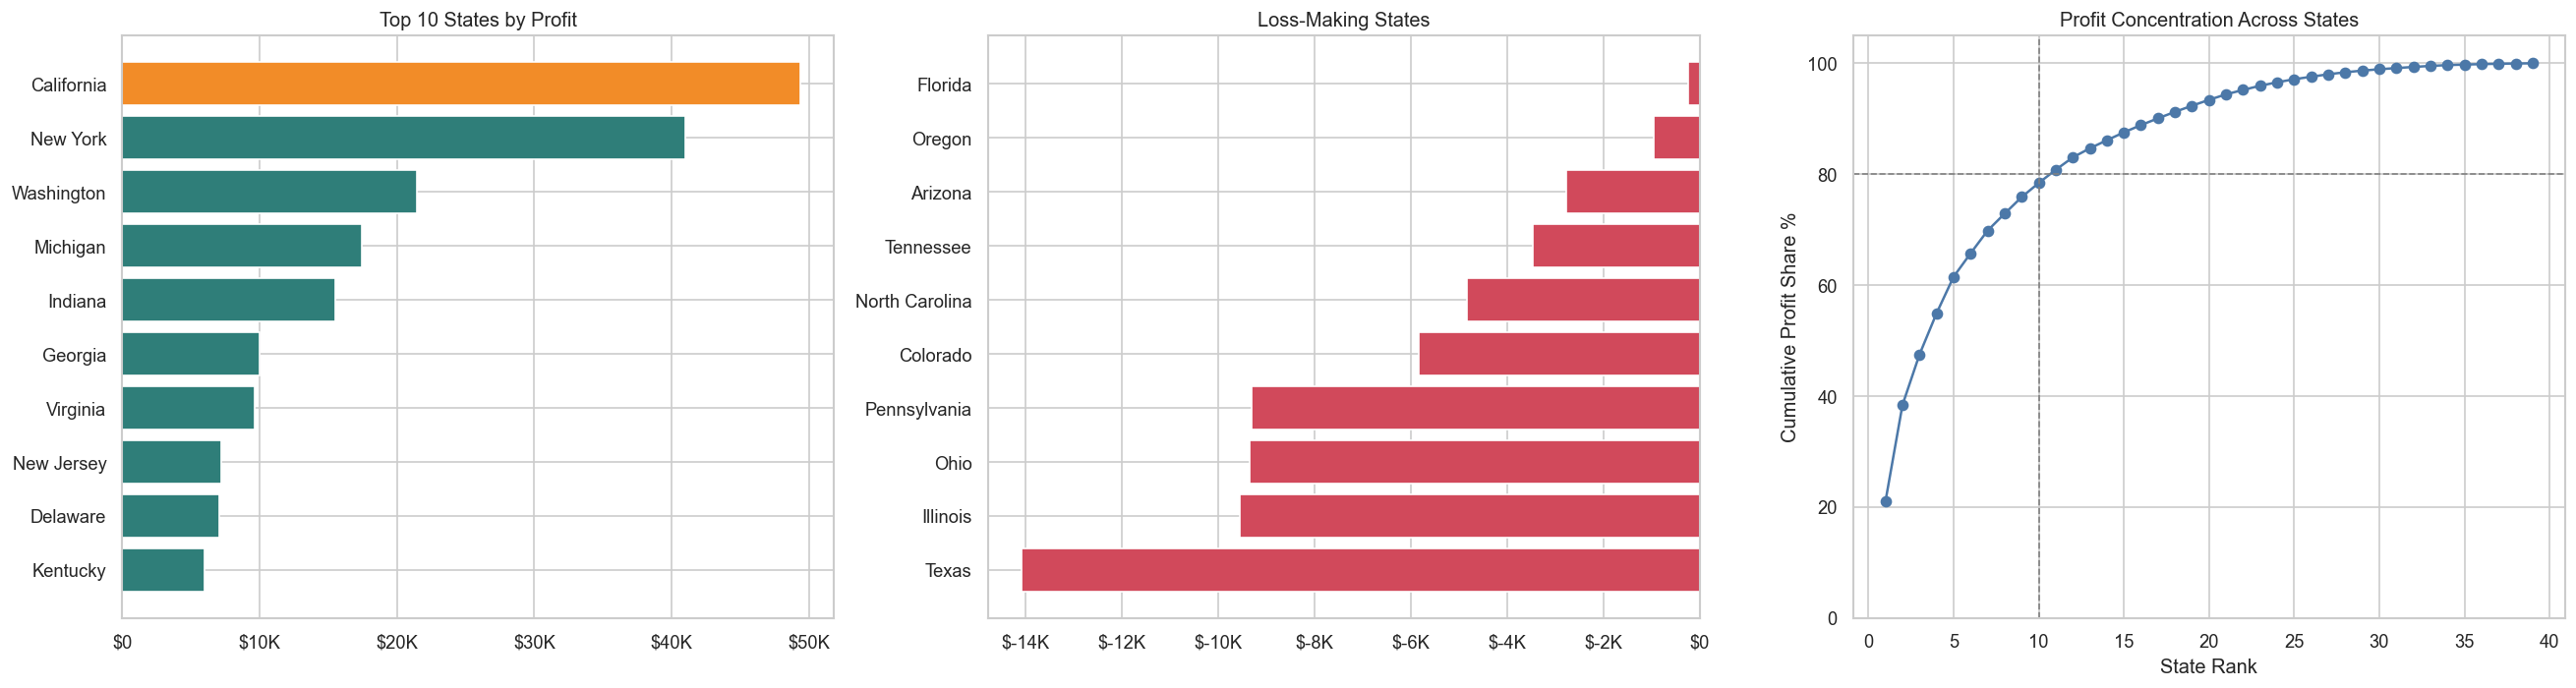

,State,Sales,Profit,Profit Margin %
3,California,"335,190.26","49,372.18",14.73
30,New York,"186,748.10","41,012.02",21.96
45,Washington,"92,975.18","21,466.66",23.09
20,Michigan,"48,504.68","17,480.28",36.04
12,Indiana,"32,039.23","15,524.66",48.46
9,Georgia,"37,260.69","9,994.42",26.82
44,Virginia,"32,721.25","9,657.49",29.51
28,New Jersey,"32,086.94","7,213.10",22.48
6,Delaware,"12,515.70","7,029.91",56.17
15,Kentucky,"24,352.73","5,968.38",24.51


In [16]:
state_summary = (
    df.groupby('State', as_index=False)
      .agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum'))
)
state_summary = add_margin(state_summary)

top_states = state_summary.sort_values('Profit', ascending=False).head(10).sort_values('Profit')
loss_states = state_summary[state_summary['Profit'] < 0].sort_values('Profit').head(10)
california = state_summary[state_summary['State'] == 'California'].iloc[0]

positive_states = state_summary[state_summary['Profit'] > 0].sort_values('Profit', ascending=False).reset_index(drop=True)
positive_states['Rank'] = positive_states.index + 1
positive_states['Cumulative Profit Share %'] = positive_states['Profit'].cumsum() / positive_states['Profit'].sum() * 100
top5_share = positive_states.head(5)['Profit'].sum() / positive_states['Profit'].sum() * 100
top10_share = positive_states.head(10)['Profit'].sum() / positive_states['Profit'].sum() * 100

print(f"Highest profit state: {top_states.iloc[-1]['State']} (${top_states.iloc[-1]['Profit']:,.2f})")
print(f"California sales: ${california['Sales']:,.2f}")
print(f"California profit: ${california['Profit']:,.2f}")
print(f"California share of total sales: {california['Sales'] / state_summary['Sales'].sum() * 100:.2f}%")
print(f"California share of total profit: {california['Profit'] / state_summary['Profit'].sum() * 100:.2f}%")
print(f"States with negative profit: {len(loss_states)}")
print(f"Top 5 positive-profit states contribute {top5_share:.2f}% of positive-state profit.")
print(f"Top 10 positive-profit states contribute {top10_share:.2f}% of positive-state profit.")

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

top_colors = [colors['profit'] if state == 'California' else colors['sales'] for state in top_states['State']]
axes[0].barh(top_states['State'], top_states['Profit'], color=top_colors)
axes[0].set_title('Top 10 States by Profit')
format_currency_axis(axes[0], axis='x')

axes[1].barh(loss_states['State'], loss_states['Profit'], color=colors['negative'])
axes[1].set_title('Loss-Making States')
format_currency_axis(axes[1], axis='x')

axes[2].plot(positive_states['Rank'], positive_states['Cumulative Profit Share %'], marker='o', color=colors['accent'])
axes[2].axhline(80, linestyle='--', color='gray', linewidth=1)
axes[2].axvline(10, linestyle='--', color='gray', linewidth=1)
axes[2].set_title('Profit Concentration Across States')
axes[2].set_xlabel('State Rank')
axes[2].set_ylabel('Cumulative Profit Share %')
axes[2].set_ylim(0, 105)

plt.tight_layout()
plt.show()

state_summary.sort_values('Profit', ascending=False).head(15).round(2)


## 6. Ship Mode Analysis

Questions answered:
- Which shipping mode is most used?
- Does faster shipping lead to higher sales?
- Which shipping mode generates the most profit?
- Is there a cost vs benefit tradeoff across shipping modes?


Most used shipping mode: Standard Class (1773 unique orders)
Highest sales by ship mode: Standard Class ($912,401.04)
Highest profit by ship mode: Standard Class ($99,767.39)
Tradeoff insight: Same Day ships fastest (~0.05 days) and has the highest average sales per order ($588.70), but it also has the lowest profit margin (9.18%).


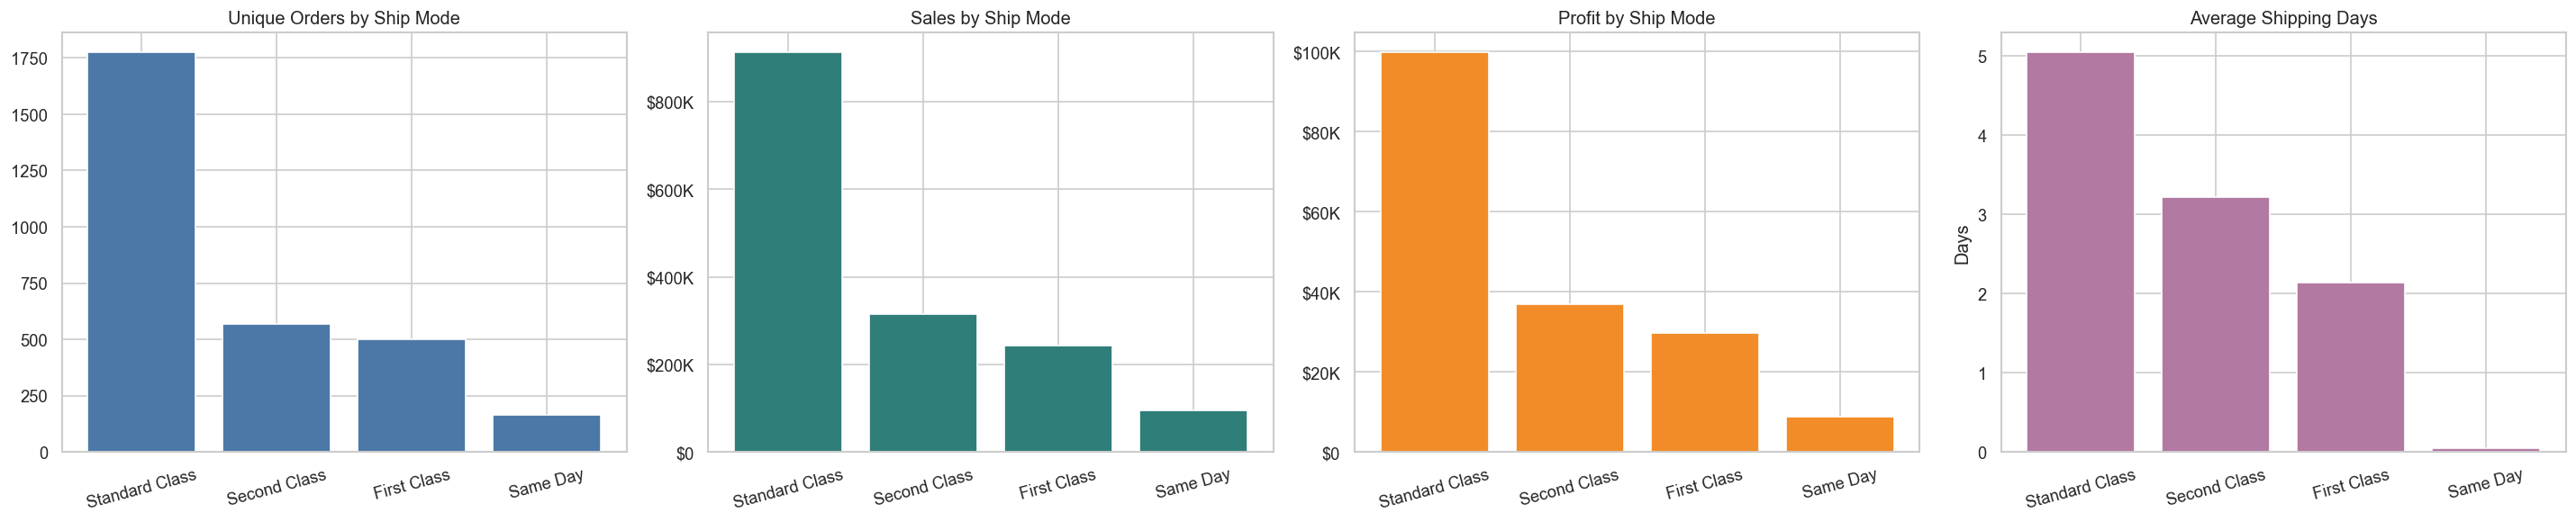

,Ship Mode,Order_Lines,Orders,Sales,Profit,Avg_Ship_Days,Profit Margin %,Avg Sales per Order
3,Standard Class,3451,1773,"912,401.04","99,767.39",5.05,10.93,514.61
2,Second Class,1147,568,"314,508.06","36,936.03",3.22,11.74,553.71
0,First Class,959,499,"242,936.72","29,749.87",2.14,12.25,486.85
1,Same Day,344,163,"95,958.50","8,808.82",0.05,9.18,588.70


In [17]:
ship_summary = (
    df.groupby('Ship Mode', as_index=False)
      .agg(
          Order_Lines=('Order ID', 'count'),
          Orders=('Order ID', 'nunique'),
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum'),
          Avg_Ship_Days=('Ship Days', 'mean')
      )
)
ship_summary = add_margin(ship_summary)
ship_summary['Avg Sales per Order'] = ship_summary['Sales'] / ship_summary['Orders']
ship_summary['Ship Mode'] = pd.Categorical(ship_summary['Ship Mode'], categories=ship_order, ordered=True)
ship_summary = ship_summary.sort_values('Ship Mode')

most_used_mode = ship_summary.loc[ship_summary['Orders'].idxmax()]
top_sales_mode = ship_summary.loc[ship_summary['Sales'].idxmax()]
top_profit_mode = ship_summary.loc[ship_summary['Profit'].idxmax()]
same_day = ship_summary[ship_summary['Ship Mode'] == 'Same Day'].iloc[0]

print(f"Most used shipping mode: {most_used_mode['Ship Mode']} ({int(most_used_mode['Orders'])} unique orders)")
print(f"Highest sales by ship mode: {top_sales_mode['Ship Mode']} (${top_sales_mode['Sales']:,.2f})")
print(f"Highest profit by ship mode: {top_profit_mode['Ship Mode']} (${top_profit_mode['Profit']:,.2f})")
print(
    f"Tradeoff insight: Same Day ships fastest (~{same_day['Avg_Ship_Days']:.2f} days) and has the highest average sales per order "
    f"(${same_day['Avg Sales per Order']:,.2f}), but it also has the lowest profit margin ({same_day['Profit Margin %']:.2f}%)."
)

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

axes[0].bar(ship_summary['Ship Mode'].astype(str), ship_summary['Orders'], color=colors['accent'])
axes[0].set_title('Unique Orders by Ship Mode')

axes[1].bar(ship_summary['Ship Mode'].astype(str), ship_summary['Sales'], color=colors['sales'])
axes[1].set_title('Sales by Ship Mode')
format_currency_axis(axes[1])

axes[2].bar(ship_summary['Ship Mode'].astype(str), ship_summary['Profit'], color=colors['profit'])
axes[2].set_title('Profit by Ship Mode')
format_currency_axis(axes[2])

axes[3].bar(ship_summary['Ship Mode'].astype(str), ship_summary['Avg_Ship_Days'], color=colors['accent3'])
axes[3].set_title('Average Shipping Days')
axes[3].set_ylabel('Days')

for ax in axes:
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

ship_summary.round(2)


## 7. Payment Mode Analysis

Questions answered:
- Which payment mode is most preferred?
- Does any payment method contribute to higher sales or profit?
- What percentage of transactions use COD vs Online vs Cards?

Note:
- `Payment Mode` changes within the same `Order ID`, so the cleanest comparison is transaction share rather than unique-customer share.


Most preferred payment mode: COD (41.57% of transactions)
Highest sales by payment mode: COD ($667,417.75)
Highest profit by payment mode: COD ($82,092.43)
Transaction share:
- COD: 41.57%
- Online: 36.67%
- Cards: 21.76%


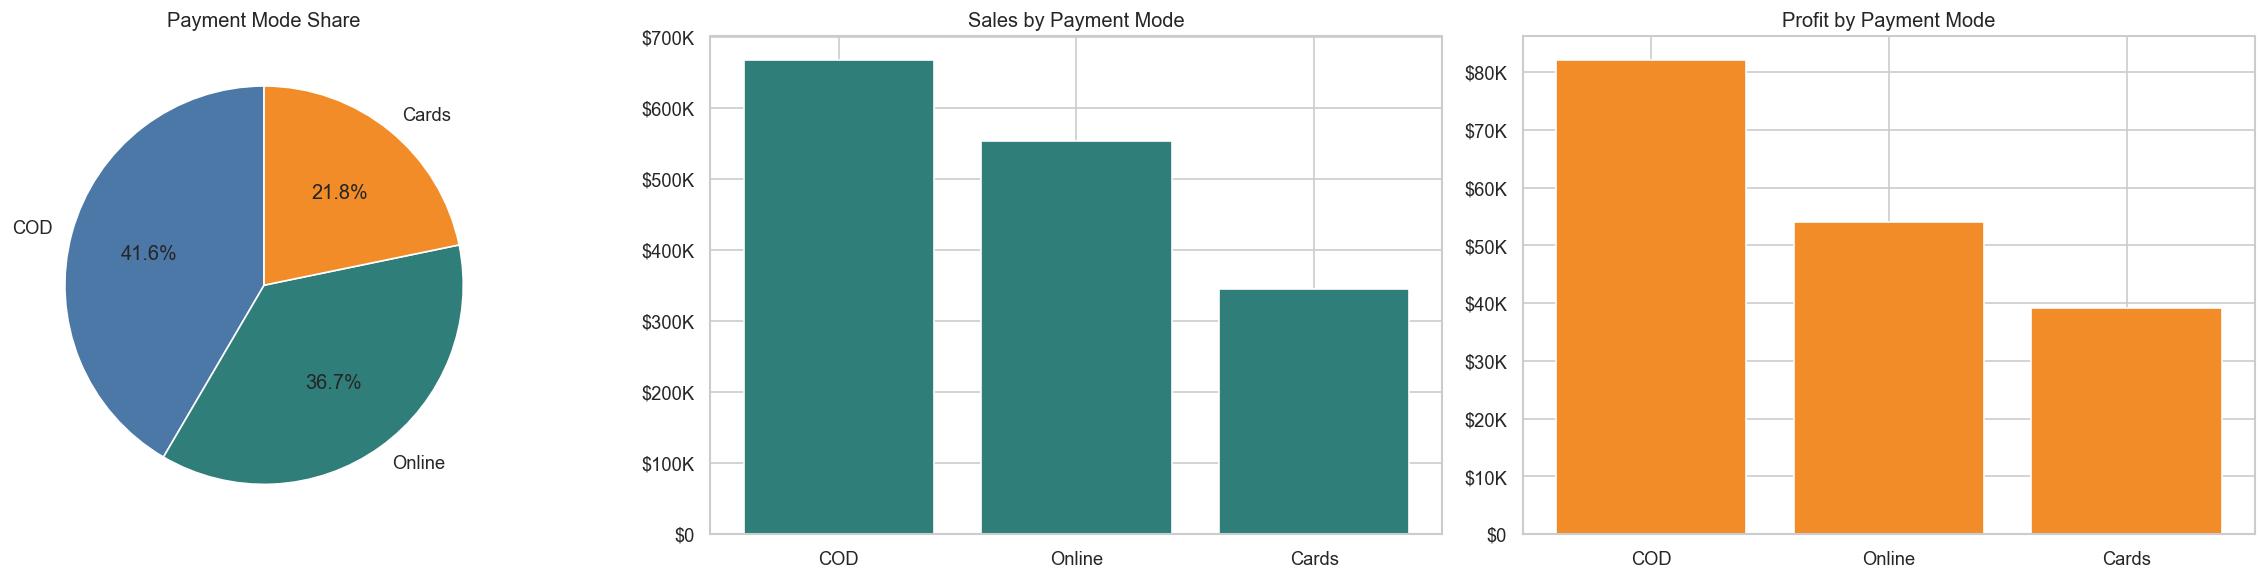

,Payment Mode,Order_Lines,Sales,Profit,Customers,Profit Margin %,Usage %,Customer Reach %
0,COD,2453,"667,417.75","82,092.42",700,12.30,41.57,90.56
2,Online,2164,"553,993.46","54,047.52",686,9.76,36.67,88.75
1,Cards,1284,"344,393.11","39,122.16",567,11.36,21.76,73.35


In [18]:
payment_summary = (
    df.groupby('Payment Mode', as_index=False)
      .agg(
          Order_Lines=('Order ID', 'count'),
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum'),
          Customers=('Customer ID', 'nunique')
      )
)
payment_summary = add_margin(payment_summary)
payment_summary['Usage %'] = payment_summary['Order_Lines'] / len(df) * 100
payment_summary['Customer Reach %'] = payment_summary['Customers'] / df['Customer ID'].nunique() * 100
payment_summary['Payment Mode'] = pd.Categorical(payment_summary['Payment Mode'], categories=payment_order, ordered=True)
payment_summary = payment_summary.sort_values('Payment Mode')

most_used_payment = payment_summary.loc[payment_summary['Order_Lines'].idxmax()]
top_sales_payment = payment_summary.loc[payment_summary['Sales'].idxmax()]
top_profit_payment = payment_summary.loc[payment_summary['Profit'].idxmax()]

print(f"Most preferred payment mode: {most_used_payment['Payment Mode']} ({most_used_payment['Usage %']:.2f}% of transactions)")
print(f"Highest sales by payment mode: {top_sales_payment['Payment Mode']} (${top_sales_payment['Sales']:,.2f})")
print(f"Highest profit by payment mode: {top_profit_payment['Payment Mode']} (${top_profit_payment['Profit']:,.2f})")
print('Transaction share:')
for _, row in payment_summary.iterrows():
    print(f"- {row['Payment Mode']}: {row['Usage %']:.2f}%")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].pie(
    payment_summary['Usage %'],
    labels=payment_summary['Payment Mode'].astype(str),
    autopct='%1.1f%%',
    startangle=90,
    colors=[colors['accent'], colors['sales'], colors['profit']]
)
axes[0].set_title('Payment Mode Share')

axes[1].bar(payment_summary['Payment Mode'].astype(str), payment_summary['Sales'], color=colors['sales'])
axes[1].set_title('Sales by Payment Mode')
format_currency_axis(axes[1])

axes[2].bar(payment_summary['Payment Mode'].astype(str), payment_summary['Profit'], color=colors['profit'])
axes[2].set_title('Profit by Payment Mode')
format_currency_axis(axes[2])

plt.tight_layout()
plt.show()

payment_summary.round(2)


## 8. Monthly Sales Trends and 9. Profit Trends

Questions answered:
- How do sales trends change month to month?
- Which month has the highest sales?
- Is there seasonality in sales?
- How does 2019 compare to 2020?
- Is there a growth trend over time?
- Are profits consistent across months?
- Are there months with losses?
- Does higher sales always mean higher profit?


Highest sales month: Dec 2020 ($166,185.85)
Weakest profit month: Apr 2020 ($933.29)
Any loss-making month: No
2019 to 2020 sales growth: 77.29%
2019 to 2020 profit growth: 14.20%
Monthly sales-profit correlation: 0.39
Seasonality: sales are strongest in Sep-Dec, with December leading overall.


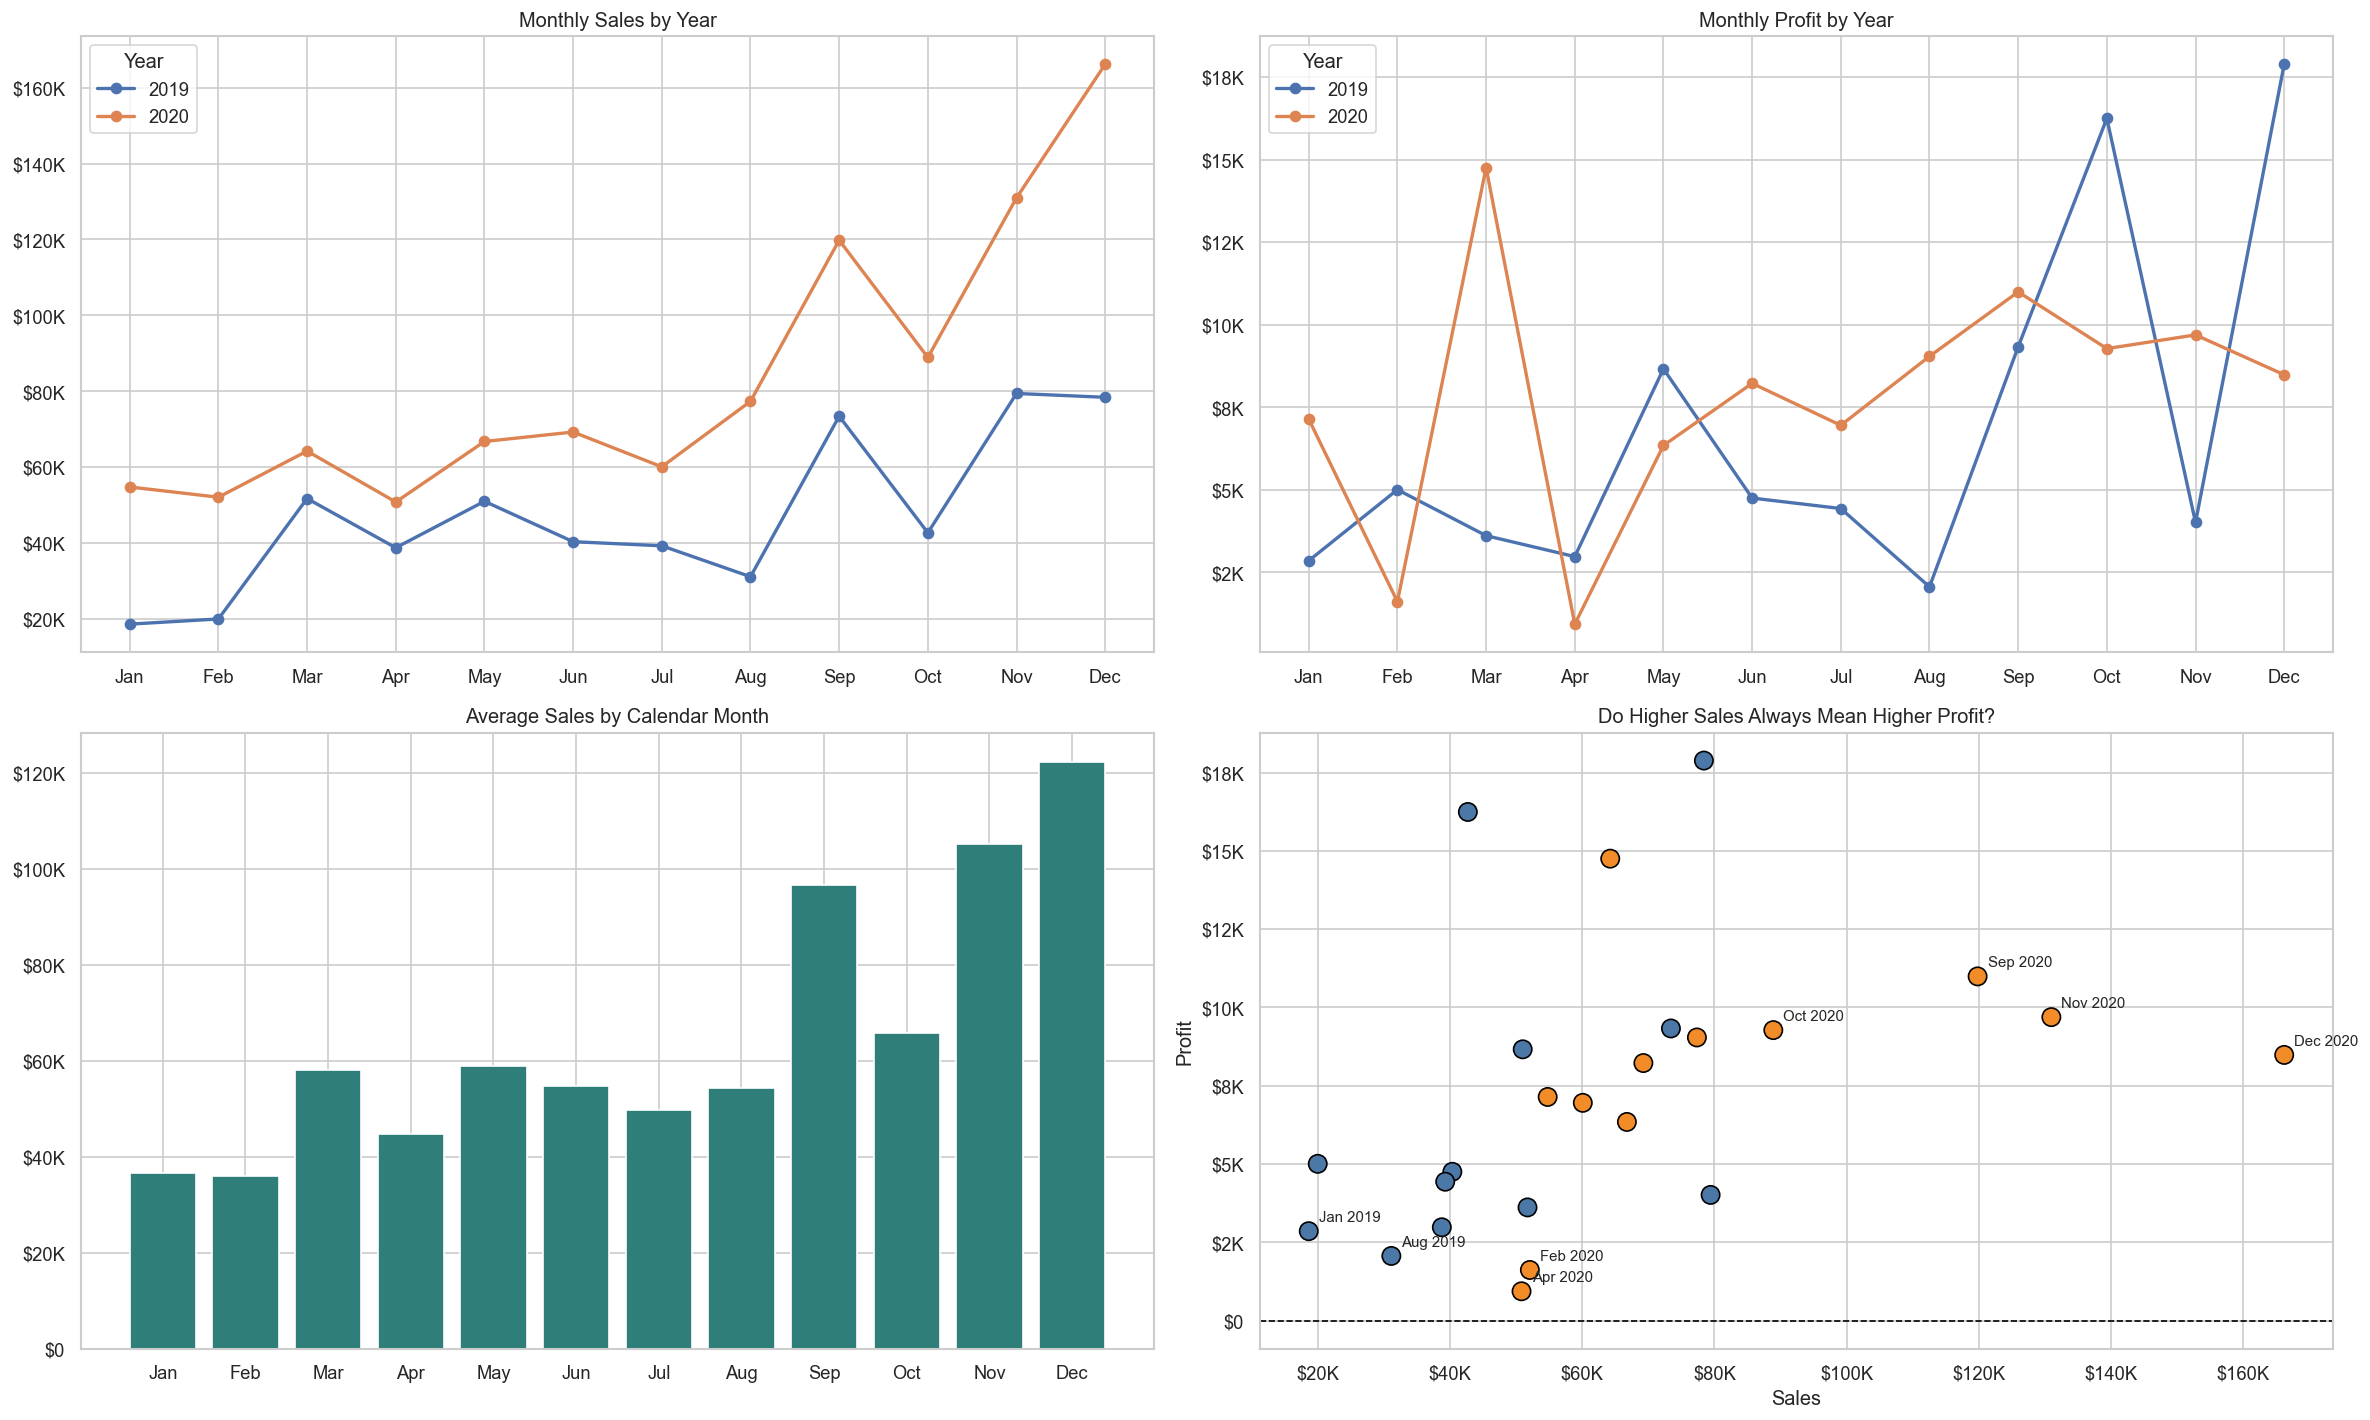

,Order Date,Sales,Profit,Year,MonthNum,Month
0,2019-01-31,"18,616.43","2,853.09",2019,1,Jan
1,2019-02-28,"19,978.81","5,004.58",2019,2,Feb
2,2019-03-31,"51,715.88","3,611.97",2019,3,Mar
3,2019-04-30,"38,750.04","2,977.81",2019,4,Apr
4,2019-05-31,"50,987.73","8,662.15",2019,5,May
5,2019-06-30,"40,344.53","4,750.38",2019,6,Jun
6,2019-07-31,"39,261.96","4,432.88",2019,7,Jul
7,2019-08-31,"31,115.37","2,062.07",2019,8,Aug
8,2019-09-30,"73,410.02","9,328.66",2019,9,Sep
9,2019-10-31,"42,687.74","16,243.14",2019,10,Oct


In [19]:
monthly = (
    df.groupby(pd.Grouper(key='Order Date', freq='ME'))
      .agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum'))
      .reset_index()
)
monthly['Year'] = monthly['Order Date'].dt.year
monthly['MonthNum'] = monthly['Order Date'].dt.month
monthly['Month'] = monthly['Order Date'].dt.strftime('%b')

avg_month = (
    monthly.groupby(['MonthNum', 'Month'], as_index=False)
           .agg(AvgSales=('Sales', 'mean'), AvgProfit=('Profit', 'mean'))
           .sort_values('MonthNum')
)
yearly = monthly.groupby('Year', as_index=False).agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum'))

peak_sales_month = monthly.loc[monthly['Sales'].idxmax()]
weakest_profit_month = monthly.loc[monthly['Profit'].idxmin()]
has_loss_month = bool((monthly['Profit'] < 0).any())
sales_profit_corr = monthly['Sales'].corr(monthly['Profit'])
sales_growth = (yearly.loc[yearly['Year'] == 2020, 'Sales'].iloc[0] / yearly.loc[yearly['Year'] == 2019, 'Sales'].iloc[0] - 1) * 100
profit_growth = (yearly.loc[yearly['Year'] == 2020, 'Profit'].iloc[0] / yearly.loc[yearly['Year'] == 2019, 'Profit'].iloc[0] - 1) * 100

print(f"Highest sales month: {peak_sales_month['Order Date'].strftime('%b %Y')} (${peak_sales_month['Sales']:,.2f})")
print(f"Weakest profit month: {weakest_profit_month['Order Date'].strftime('%b %Y')} (${weakest_profit_month['Profit']:,.2f})")
print(f"Any loss-making month: {'Yes' if has_loss_month else 'No'}")
print(f"2019 to 2020 sales growth: {sales_growth:.2f}%")
print(f"2019 to 2020 profit growth: {profit_growth:.2f}%")
print(f"Monthly sales-profit correlation: {sales_profit_corr:.2f}")
print('Seasonality: sales are strongest in Sep-Dec, with December leading overall.')

fig, axes = plt.subplots(2, 2, figsize=(20, 12))

for year, group in monthly.groupby('Year'):
    axes[0, 0].plot(group['MonthNum'], group['Sales'], marker='o', linewidth=2, label=str(year))
axes[0, 0].set_title('Monthly Sales by Year')
axes[0, 0].set_xticks(range(1, 13))
axes[0, 0].set_xticklabels(month_order)
axes[0, 0].legend(title='Year')
format_currency_axis(axes[0, 0])

for year, group in monthly.groupby('Year'):
    axes[0, 1].plot(group['MonthNum'], group['Profit'], marker='o', linewidth=2, label=str(year))
axes[0, 1].set_title('Monthly Profit by Year')
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].set_xticklabels(month_order)
axes[0, 1].legend(title='Year')
format_currency_axis(axes[0, 1])

axes[1, 0].bar(avg_month['Month'], avg_month['AvgSales'], color=colors['sales'])
axes[1, 0].set_title('Average Sales by Calendar Month')
format_currency_axis(axes[1, 0])

year_color_map = {2019: colors['accent'], 2020: colors['profit']}
scatter_colors = monthly['Year'].map(year_color_map)
axes[1, 1].scatter(monthly['Sales'], monthly['Profit'], c=scatter_colors, s=120, edgecolor='black')
axes[1, 1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1, 1].set_title('Do Higher Sales Always Mean Higher Profit?')
axes[1, 1].set_xlabel('Sales')
axes[1, 1].set_ylabel('Profit')
format_currency_axis(axes[1, 1], axis='x')
format_currency_axis(axes[1, 1], axis='y')

labels_to_annotate = pd.concat([monthly.nlargest(4, 'Sales'), monthly.nsmallest(4, 'Profit')]).drop_duplicates('Order Date')
for _, row in labels_to_annotate.iterrows():
    axes[1, 1].annotate(
        row['Order Date'].strftime('%b %Y'),
        (row['Sales'], row['Profit']),
        xytext=(6, 6),
        textcoords='offset points',
        fontsize=9,
    )

plt.tight_layout()
plt.show()

monthly.assign(Sales=monthly['Sales'].round(2), Profit=monthly['Profit'].round(2))


## 10. Advanced Business Insights

Questions answered:
- Which `Region + Category + Segment + Ship Mode` combination performs best?
- Where should the company focus to increase profit?
- Which areas need cost reduction or strategy change?

To avoid over-interpreting tiny slices, the main recommendation view below focuses on combinations with at least `$25K` in sales.


Highest absolute-profit combo: Central | Technology | Corporate | Standard Class ($9,979.80 profit on $10,947.54 sales)
Best scalable combo: West | Office Supplies | Corporate | Standard Class ($8,903.24 profit on $44,992.68 sales)

Where to focus to increase profit:
- Scale West and East combinations in Office Supplies and Technology, especially Standard Class, because they combine strong volume with solid profit.
- Protect California and other top-performing West states, because a large share of total profit is concentrated there.
- Keep leveraging Consumer for revenue, but improve margin through product mix and pricing discipline.

Where strategy or cost reduction is needed:
- Furniture needs attention, especially Tables and low-margin Furniture combinations in Central, West, and South.
- Review loss-making slices such as Central | Office Supplies | Corporate | Standard Class and Central | Furniture | Consumer | Standard Class.
- Same Day delivers speed, but its margin is weaker ove

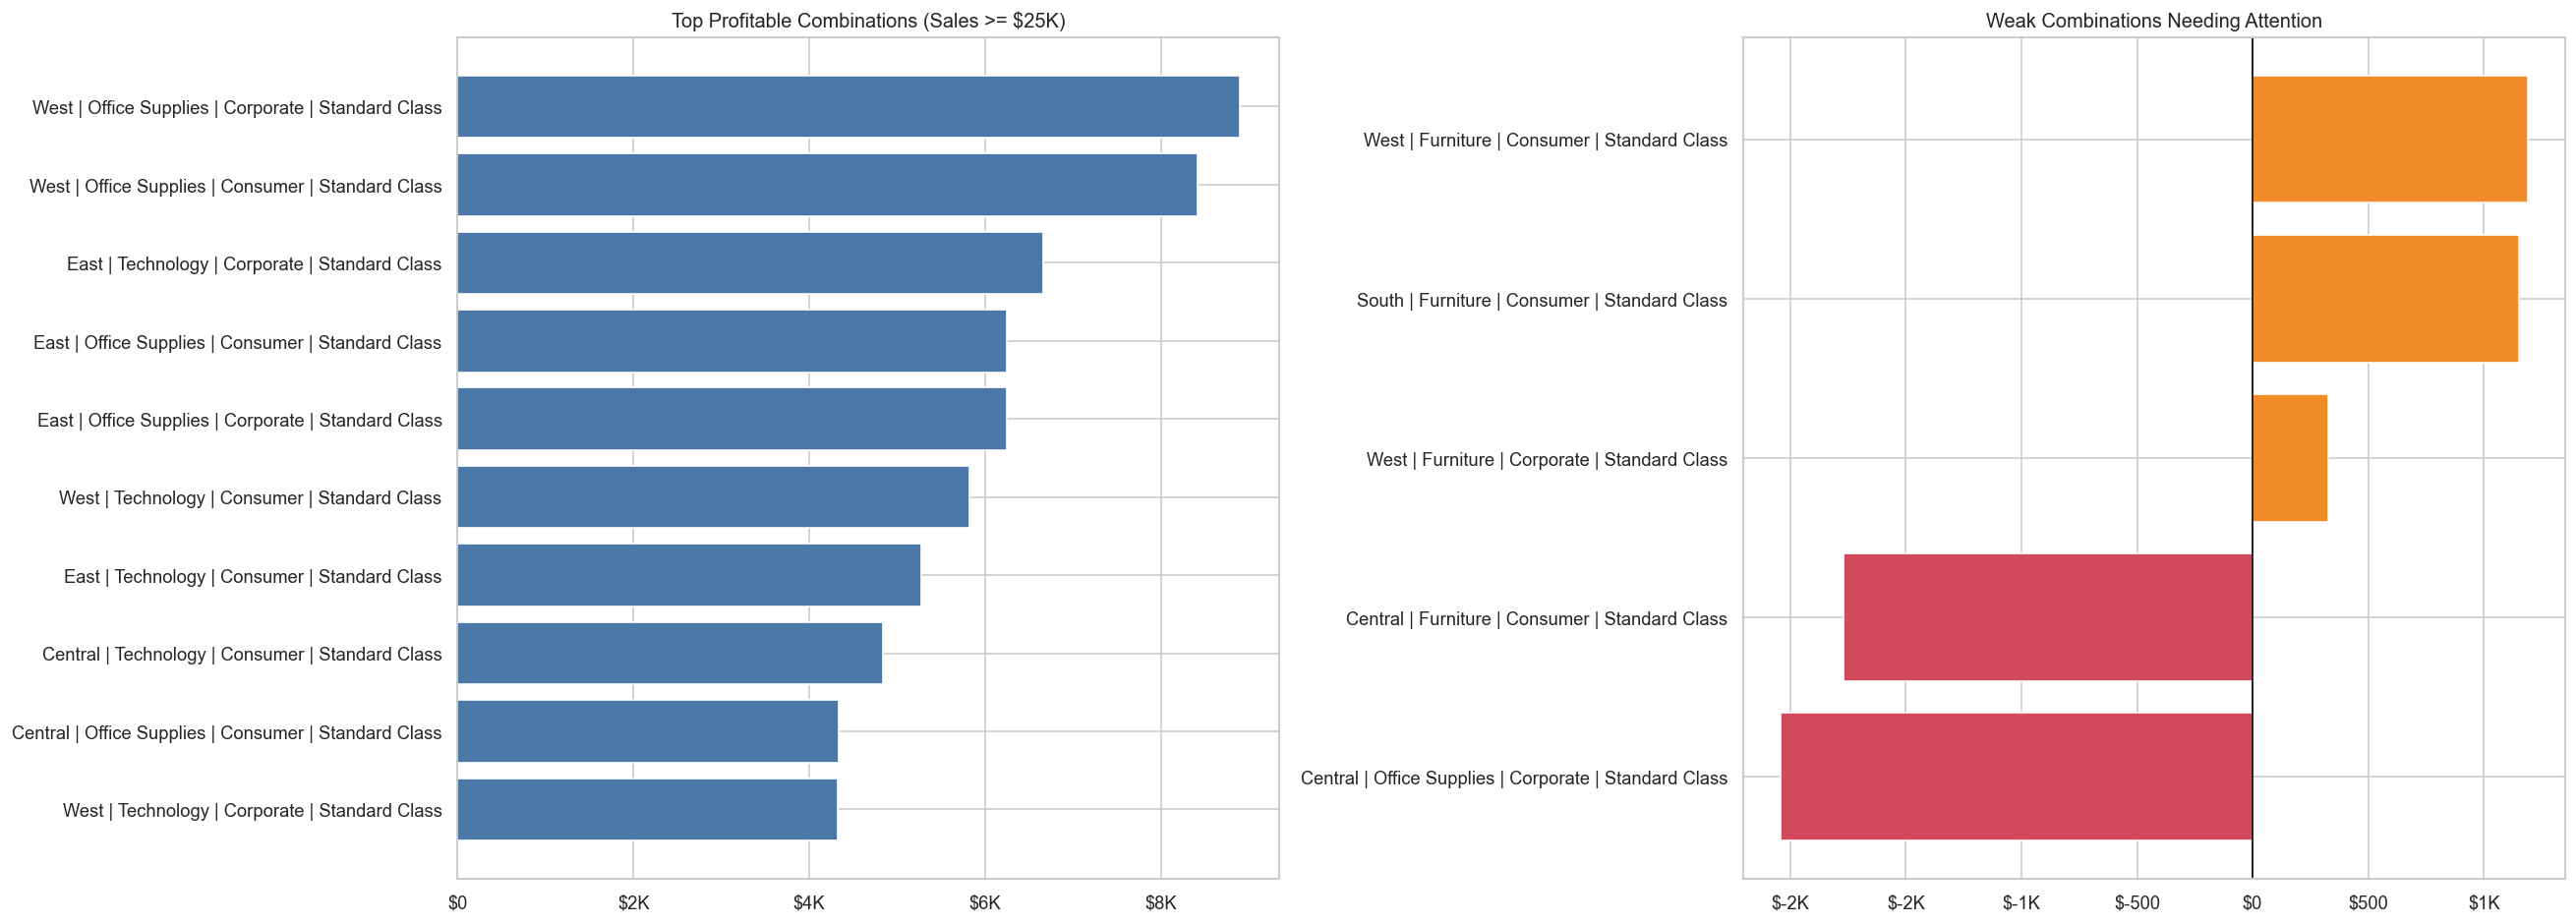

,Region,Category,Segment,Ship Mode,Sales,Profit,Orders,Profit Margin %,Combo
126,West,Office Supplies,Corporate,Standard Class,"44,992.68","8,903.24",120,19.79,West | Office Supplies | Corporate | Standard ...
122,West,Office Supplies,Consumer,Standard Class,"58,568.12","8,422.90",205,14.38,West | Office Supplies | Consumer | Standard C...
66,East,Technology,Corporate,Standard Class,"36,407.88","6,660.35",56,18.29,East | Technology | Corporate | Standard Class
50,East,Office Supplies,Consumer,Standard Class,"54,053.97","6,245.88",184,11.55,East | Office Supplies | Consumer | Standard C...
54,East,Office Supplies,Corporate,Standard Class,"38,530.10","6,244.49",120,16.21,East | Office Supplies | Corporate | Standard ...
134,West,Technology,Consumer,Standard Class,"36,117.92","5,822.29",79,16.12,West | Technology | Consumer | Standard Class
62,East,Technology,Consumer,Standard Class,"44,403.16","5,273.57",73,11.88,East | Technology | Consumer | Standard Class
27,Central,Technology,Consumer,Standard Class,"28,620.67","4,837.13",71,16.90,Central | Technology | Consumer | Standard Class
15,Central,Office Supplies,Consumer,Standard Class,"46,656.64","4,335.24",164,9.29,Central | Office Supplies | Consumer | Standar...
138,West,Technology,Corporate,Standard Class,"28,214.94","4,319.16",57,15.31,West | Technology | Corporate | Standard Class


In [20]:
combo_summary = (
    df.groupby(['Region', 'Category', 'Segment', 'Ship Mode'], as_index=False)
      .agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum'), Orders=('Order ID', 'nunique'))
)
combo_summary = add_margin(combo_summary)
combo_summary['Combo'] = (
    combo_summary['Region'] + ' | ' + combo_summary['Category'] + ' | ' +
    combo_summary['Segment'] + ' | ' + combo_summary['Ship Mode']
)

best_absolute_combo = combo_summary.sort_values(['Profit', 'Sales'], ascending=[False, False]).iloc[0]
practical_combos = combo_summary[combo_summary['Sales'] >= 25000].sort_values(['Profit', 'Sales'], ascending=[False, False])
best_practical_combo = practical_combos.iloc[0]
weak_combos = combo_summary[
    (combo_summary['Sales'] >= 25000)
    & ((combo_summary['Profit'] < 0) | (combo_summary['Profit Margin %'] < 5))
].sort_values('Profit')

print(
    f"Highest absolute-profit combo: {best_absolute_combo['Combo']} "
    f"(${best_absolute_combo['Profit']:,.2f} profit on ${best_absolute_combo['Sales']:,.2f} sales)"
)
print(
    f"Best scalable combo: {best_practical_combo['Combo']} "
    f"(${best_practical_combo['Profit']:,.2f} profit on ${best_practical_combo['Sales']:,.2f} sales)"
)
print('\nWhere to focus to increase profit:')
print('- Scale West and East combinations in Office Supplies and Technology, especially Standard Class, because they combine strong volume with solid profit.')
print('- Protect California and other top-performing West states, because a large share of total profit is concentrated there.')
print('- Keep leveraging Consumer for revenue, but improve margin through product mix and pricing discipline.')
print('\nWhere strategy or cost reduction is needed:')
print('- Furniture needs attention, especially Tables and low-margin Furniture combinations in Central, West, and South.')
print('- Review loss-making slices such as Central | Office Supplies | Corporate | Standard Class and Central | Furniture | Consumer | Standard Class.')
print('- Same Day delivers speed, but its margin is weaker overall, so it should be used selectively.')

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

top_practical = practical_combos.head(10).sort_values('Profit')
axes[0].barh(top_practical['Combo'], top_practical['Profit'], color=colors['accent'])
axes[0].set_title('Top Profitable Combinations (Sales >= $25K)')
format_currency_axis(axes[0], axis='x')

weak_plot = weak_combos.copy()
weak_plot['Bar Color'] = np.where(weak_plot['Profit'] < 0, colors['negative'], colors['profit'])
axes[1].barh(weak_plot['Combo'], weak_plot['Profit'], color=weak_plot['Bar Color'])
axes[1].set_title('Weak Combinations Needing Attention')
format_currency_axis(axes[1], axis='x')
axes[1].axvline(0, color='black', linewidth=1)

plt.tight_layout()
plt.show()

practical_combos.head(12).round(2)
